In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

In [2]:
# 1. Load real-world dataset
wine = load_wine()
X = wine.data
feature_names = wine.feature_names
y = wine.target

In [6]:
# Create DataFrame
df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

# Add target column
df["target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [7]:
# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit Factor Analysis
fa = FactorAnalysis(
    n_components=2,
    rotation="varimax",
    random_state=42
)

X_factors = fa.fit_transform(X_scaled)

# 4. Create factor scores dataframe
factor_df = pd.DataFrame(
    X_factors,
    columns=["Factor 1", "Factor 2"]
)
factor_df["wine_class"] = y
factor_df.head()



,Factor 1,Factor 2,wine_class
0,1.236551,0.592958,0
1,0.817237,-0.101991,0
2,1.148114,0.532815,0
3,1.676831,1.700543,0
4,0.637762,0.042249,0


In [8]:
# 5. View loadings
loadings = pd.DataFrame(
    fa.components_.T,
    index=feature_names,
    columns=["Factor 1", "Factor 2"]
)

print("\nFactor Loadings:")
print(loadings.sort_values("Factor 1", ascending=False))


Factor Loadings:
                              Factor 1  Factor 2
flavanoids                    0.959211  0.023523
total_phenols                 0.885182  0.135010
od280/od315_of_diluted_wines  0.829244 -0.263248
proanthocyanins               0.659725  0.092244
hue                           0.584037 -0.402649
proline                       0.525284  0.514814
alcohol                       0.251149  0.695508
magnesium                     0.217281  0.316037
ash                           0.079660  0.315576
color_intensity              -0.208969  0.877494
alcalinity_of_ash            -0.387335 -0.097329
malic_acid                   -0.437276  0.218823
nonflavanoid_phenols         -0.560597  0.016222


<h2>What Do the Factor Values Mean?</h2>

<p>
The table below shows the estimated values of the hidden factors for each wine:
</p>

<table>
  <tr>
    <th>Wine</th>
    <th>Factor 1</th>
    <th>Factor 2</th>
    <th>wine_class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>1.236551</td>
    <td>0.592958</td>
    <td>0</td>
  </tr>
  <tr>
    <td>1</td>
    <td>0.817237</td>
    <td>-0.101991</td>
    <td>0</td>
  </tr>
</table>

<p>
These numbers are the estimated latent variables:
</p>

<p>
\[
z^{(i)} =
\begin{bmatrix}
z_1^{(i)} \\
z_2^{(i)}
\end{bmatrix}
\]
</p>

<p>
For example, wine 0 has:
</p>

<p>
\[
z^{(0)} =
\begin{bmatrix}
1.236551 \\
0.592958
\end{bmatrix}
\]
</p>

<p>
This means wine 0 scores high on Factor 1 and moderately high on Factor 2.
</p>

<hr>

<h2>But What Do Factor 1 and Factor 2 Represent?</h2>

<p>
The factor values alone do not tell us the meaning of each factor.
To understand what each factor represents, we need to inspect the loading matrix:
</p>

<pre><code class="language-python">
loadings = pd.DataFrame(
    fa.components_.T,
    index=X.columns,
    columns=["Factor1", "Factor2"]
)

print(loadings)
</code></pre>

<p>
The loading matrix tells us how strongly each original feature is connected to each factor.
</p>

<hr>

<h2>Example Interpretation</h2>

<p>
Suppose the loading matrix looks like this:
</p>

<table>
  <tr>
    <th>Feature</th>
    <th>Factor 1</th>
    <th>Factor 2</th>
  </tr>
  <tr>
    <td>alcohol</td>
    <td>0.85</td>
    <td>0.10</td>
  </tr>
  <tr>
    <td>proline</td>
    <td>0.91</td>
    <td>0.05</td>
  </tr>
  <tr>
    <td>flavanoids</td>
    <td>0.88</td>
    <td>-0.20</td>
  </tr>
  <tr>
    <td>color_intensity</td>
    <td>0.15</td>
    <td>0.82</td>
  </tr>
  <tr>
    <td>malic_acid</td>
    <td>-0.10</td>
    <td>0.79</td>
  </tr>
</table>

<h3>Factor 1</h3>

<p>
Factor 1 is strongly related to:
</p>

<ul>
  <li>alcohol</li>
  <li>proline</li>
  <li>flavanoids</li>
</ul>

<p>
So we might interpret Factor 1 as:
</p>

<blockquote>
  Wine richness / body / quality factor
</blockquote>

<h3>Factor 2</h3>

<p>
Factor 2 is strongly related to:
</p>

<ul>
  <li>color_intensity</li>
  <li>malic_acid</li>
</ul>

<p>
So we might interpret Factor 2 as:
</p>

<blockquote>
  Acidity and color factor
</blockquote>

<hr>

<h2>Interpreting One Row</h2>

<p>
For wine 0:
</p>

<p>
\[
\text{Factor 1} = 1.236551
\]
</p>

<p>
\[
\text{Factor 2} = 0.592958
\]
</p>

<p>
If Factor 1 means “wine richness” and Factor 2 means “acidity/color,” then wine 0 can be interpreted as:
</p>

<blockquote>
  Richer than average and moderately high in acidity/color.
</blockquote>

<hr>

<h2>Main Idea</h2>

<p>
Originally, each wine had 13 measured features:
</p>

<ul>
  <li>alcohol</li>
  <li>malic_acid</li>
  <li>ash</li>
  <li>magnesium</li>
  <li>flavanoids</li>
  <li>proline</li>
  <li>etc.</li>
</ul>

<p>
So each wine originally lived in:
</p>

<p>
\[
\mathbb{R}^{13}
\]
</p>

<p>
After Factor Analysis with 2 factors, each wine is represented in:
</p>

<p>
\[
\mathbb{R}^{2}
\]
</p>

<p>
For example:
</p>

<pre><code>
Wine 0 → (1.236551, 0.592958)
Wine 1 → (0.817237, -0.101991)
Wine 2 → (1.148114, 0.532815)
</code></pre>

<p>
These are the estimated hidden coordinates of each wine.
</p>

<hr>

<h2>Important Takeaway</h2>

<p>
The factors are hidden variables. Factor Analysis discovers them from the correlations in the observed data.
</p>

<p>
However, the factors do not automatically come with names. We interpret them by looking at the loading matrix.
</p>

<p>
In Andrew Ng's notation:
</p>

<p>
\[
x = \mu + \Lambda z + \epsilon
\]
</p>

<p>
where:
</p>

<ul>
  <li>\(x\) = observed wine features</li>
  <li>\(z\) = hidden factors</li>
  <li>\(\Lambda\) = loading matrix</li>
  <li>\(\epsilon\) = noise</li>
</ul>

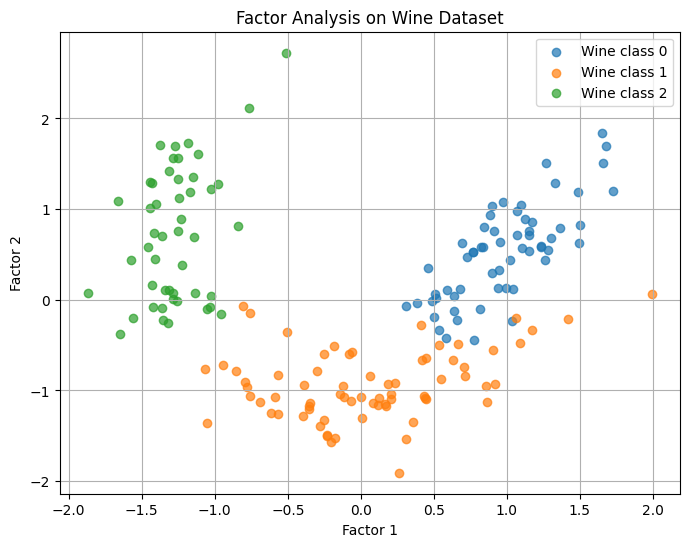

In [9]:
# 6. Plot the two latent factors
plt.figure(figsize=(8, 6))

for class_id in sorted(factor_df["wine_class"].unique()):
    subset = factor_df[factor_df["wine_class"] == class_id]
    plt.scatter(
        subset["Factor 1"],
        subset["Factor 2"],
        label=f"Wine class {class_id}",
        alpha=0.7
    )

plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Factor Analysis on Wine Dataset")
plt.legend()
plt.grid(True)
plt.show()

<h1>What Can I Do With a Factor Analysis Model?</h1>

<p>
Many people learn Factor Analysis and stop at "it finds latent factors."
The real value comes from what you can do <strong>after</strong> you've built the model.
</p>

<hr>

<h2>1. Compress High-Dimensional Data</h2>

<p>
Originally each wine had 13 features:
</p>

<pre>
alcohol
malic_acid
ash
...
proline
</pre>

<p>
After Factor Analysis:
</p>

<pre>
Factor1
Factor2
</pre>

<p>
Now every wine is represented by only 2 numbers.
</p>

<p>
Instead of:
</p>

<p>
\(x \in \mathbb{R}^{13}\)
</p>

<p>
you have:
</p>

<p>
\(z \in \mathbb{R}^{2}\)
</p>

<h3>Use Cases</h3>

<ul>
<li>Faster machine learning</li>
<li>Lower storage requirements</li>
<li>Easier visualization</li>
<li>Simpler clustering</li>
</ul>

<hr>

<h2>2. Visualize Hidden Structure</h2>

<p>
Plot the latent factors:
</p>

<pre><code class="language-python">
plt.scatter(
    factor_df["Factor 1"],
    factor_df["Factor 2"]
)
</code></pre>

<p>
You may discover that classes naturally separate in latent space.
</p>

<pre>
         Class 1

      ● ● ● ●

 Class 2      Class 0

● ● ●        ● ● ●
</pre>

<p>
This structure may be difficult to see in the original 13-dimensional feature space.
</p>

<hr>

<h2>3. Discover Hidden Concepts</h2>

<p>
Suppose the loading matrix shows:
</p>

<table border="1">
<tr>
<th>Feature</th>
<th>Factor 1</th>
</tr>
<tr>
<td>alcohol</td>
<td>0.85</td>
</tr>
<tr>
<td>proline</td>
<td>0.91</td>
</tr>
<tr>
<td>flavanoids</td>
<td>0.88</td>
</tr>
</table>

<p>
Then Factor 1 may represent:
</p>

<blockquote>
Wine richness / body
</blockquote>

<p>
The model discovered a hidden concept that was not explicitly present in the dataset.
</p>

<hr>

<h2>4. Clustering</h2>

<p>
Instead of clustering the original features:
</p>

<pre><code class="language-python">
KMeans().fit(X_scaled)
</code></pre>

<p>
Cluster the latent factors:
</p>

<pre><code class="language-python">
KMeans().fit(X_factors)
</code></pre>

<p>
Now clustering occurs in latent space rather than the original feature space.
</p>

<p>
Often this produces cleaner and more meaningful groups.
</p>

<hr>

<h2>5. Build Predictive Models</h2>

<p>
Instead of training on the original features:
</p>

<pre><code class="language-python">
model.fit(X, y)
</code></pre>

<p>
Train on the latent factors:
</p>

<pre><code class="language-python">
model.fit(X_factors, y)
</code></pre>

<p>
Example:
</p>

<pre><code class="language-python">
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_factors, y)
</code></pre>

<h3>Benefits</h3>

<ul>
<li>Reduced noise</li>
<li>Fewer features</li>
<li>Faster training</li>
<li>Sometimes better generalization</li>
</ul>

<hr>

<h2>6. Noise Reduction</h2>

<p>
Recall the Factor Analysis model:
</p>

<p>
\(x=\mu+\Lambda z+\epsilon\)
</p>

<p>
where:
</p>

<pre>
signal = Λz
noise  = ε
</pre>

<p>
Factor Analysis attempts to separate signal from noise.
</p>

<p>
You can reconstruct denoised observations:
</p>

<pre><code class="language-python">
X_reconstructed = fa.inverse_transform(X_factors)
</code></pre>

<p>
The reconstructed data often contains less noise than the original observations.
</p>

<hr>

<h2>7. Find Similar Wines</h2>

<p>
Instead of comparing all 13 features, compare latent factors:
</p>

<pre><code class="language-python">
distance(
    wine1_factors,
    wine2_factors
)
</code></pre>

<p>
Because latent factors capture the underlying structure, similarity calculations are often more meaningful.
</p>

<hr>

<h2>8. Recommendation Systems</h2>

<p>
One of the most important real-world applications.
</p>

<p>
Suppose we have:
</p>

<pre>
Users × Movies
</pre>

<p>
Factor Analysis can discover hidden preferences:
</p>

<pre>
Action preference
Romance preference
Comedy preference
</pre>

<p>
Users and movies are mapped into the same latent space.
</p>

<p>
Recommendations are made using those hidden factors.
</p>

<p>
This idea is closely related to matrix factorization methods used by Netflix and other recommendation systems.
</p>

<hr>

<h2>9. Anomaly Detection</h2>

<p>
After fitting Factor Analysis, ask:
</p>

<blockquote>
How well can each observation be explained by the latent factors?
</blockquote>

<p>
Compute reconstruction error:
</p>

<pre><code class="language-python">
error = np.linalg.norm(
    x - reconstructed_x
)
</code></pre>

<p>
Large errors may indicate unusual observations.
</p>

<h3>Applications</h3>

<ul>
<li>Fraud detection</li>
<li>Manufacturing quality control</li>
<li>Sensor monitoring</li>
<li>Network intrusion detection</li>
</ul>

<hr>

<h2>10. Understand Correlations</h2>

<p>
Recall:
</p>

<p>
\(Cov(x)=\Lambda\Lambda^T+\Psi\)
</p>

<p>
The term:
</p>

<p>
\(\Lambda\Lambda^T\)
</p>

<p>
captures correlations explained by hidden factors.
</p>

<p>
This is heavily used in psychology and social sciences.
</p>

<p>
Example:
</p>

<pre>
Math
Physics
Chemistry
Programming
</pre>

<p>
Factor Analysis may discover:
</p>

<pre>
General Intelligence
</pre>

<p>
as the hidden factor that explains the correlations among these subjects.
</p>

<hr>

<h2>Practical Analysis Workflow</h2>

<pre><code class="language-python">
# Examine latent factors
print(X_factors[:10])

# Examine loadings
print(loadings)

# Visualize latent space
plt.scatter(
    X_factors[:, 0],
    X_factors[:, 1],
    c=y
)
plt.colorbar()
plt.show()
</code></pre>

<h3>Questions to Investigate</h3>

<ol>
<li>What hidden factors exist?</li>
<li>Do classes separate naturally in latent space?</li>
<li>Which original features define each factor?</li>
<li>Are there outliers?</li>
<li>Can these factors improve clustering or prediction?</li>
</ol>

<hr>

<h2>Main Takeaway</h2>

<p>
Factor Analysis assumes:
</p>

<p>
\(x = \mu + \Lambda z + \epsilon\)
</p>

<p>
where:
</p>

<ul>
<li><strong>x</strong> = observed variables</li>
<li><strong>z</strong> = hidden factors</li>
<li><strong>Λ</strong> = loading matrix</li>
<li><strong>ε</strong> = noise</li>
</ul>

<p>
After training, the latent factors <strong>z</strong> provide a compact representation of the data that can be used for:
</p>

<ul>
<li>Dimensionality reduction</li>
<li>Visualization</li>
<li>Clustering</li>
<li>Prediction</li>
<li>Recommendation systems</li>
<li>Noise reduction</li>
<li>Anomaly detection</li>
<li>Understanding hidden causes behind observed correlations</li>
</ul>

<h1>Factor Analysis vs EM Algorithm</h1>

<p>
One of the most common sources of confusion is thinking that Factor Analysis and EM are competing algorithms.
They are not.
</p>

<p>
The correct relationship is:
</p>

<blockquote>
Factor Analysis is a model.
<br>
EM is an algorithm used to learn the parameters of that model.
</blockquote>

<hr>

<h2>Analogy</h2>

<table border="1">
<tr>
<th>Model</th>
<th>Learning Algorithm</th>
</tr>
<tr>
<td>Linear Regression</td>
<td>Gradient Descent</td>
</tr>
<tr>
<td>Logistic Regression</td>
<td>Gradient Descent</td>
</tr>
<tr>
<td>Factor Analysis</td>
<td>EM Algorithm</td>
</tr>
<tr>
<td>Gaussian Mixture Model</td>
<td>EM Algorithm</td>
</tr>
</table>

<p>
A model describes how data is generated.
A learning algorithm estimates the parameters of that model.
</p>

<hr>

<h2>Factor Analysis = The Model</h2>

<p>
Factor Analysis assumes that observed variables are generated from hidden factors.
</p>

<p>
The model is:
</p>

<p>
\[
x = \mu + \Lambda z + \epsilon
\]
</p>

<p>
where:
</p>

<ul>
<li><strong>x</strong> = observed variables</li>
<li><strong>z</strong> = hidden (latent) factors</li>
<li><strong>\(\Lambda\)</strong> = loading matrix</li>
<li><strong>\(\mu\)</strong> = mean vector</li>
<li><strong>\(\epsilon\)</strong> = Gaussian noise</li>
</ul>

<p>
This equation describes how the data was generated.
</p>

<hr>

<h3>What Factor Analysis Tries to Answer</h3>

<ul>
<li>What hidden factors exist?</li>
<li>How many latent dimensions explain the data?</li>
<li>Which observed variables are influenced by which factors?</li>
<li>What covariance structure explains the observed correlations?</li>
</ul>

<hr>

<h2>EM = The Learning Algorithm</h2>

<p>
Once we decide that the data follows the Factor Analysis model,
we still do not know the values of:
</p>

<p>
\[
\mu,\Lambda,\Psi
\]
</p>

<p>
These parameters must be estimated from data.
</p>

<p>
EM is the algorithm used to estimate them.
</p>

<hr>

<h3>What EM Does</h3>

<p>
EM alternates between two steps:
</p>

<h4>E-Step</h4>

<p>
Estimate the hidden factors:
</p>

<p>
\[
E[z^{(i)}|x^{(i)}]
\]
</p>

<p>
For every observation, compute the expected latent variables.
</p>

<h4>M-Step</h4>

<p>
Update:
</p>

<p>
\[
\mu,\Lambda,\Psi
\]
</p>

<p>
using the latent variable estimates from the E-Step.
</p>

<p>
Repeat until convergence.
</p>

<hr>

<h2>Why Do We Need EM?</h2>

<p>
Suppose we observe:
</p>

<table border="1">
<tr>
<th>Wine</th>
<th>Alcohol</th>
<th>Flavanoids</th>
</tr>
<tr>
<td>1</td>
<td>14.2</td>
<td>3.0</td>
</tr>
<tr>
<td>2</td>
<td>13.5</td>
<td>2.8</td>
</tr>
</table>

<p>
But we never observe:
</p>

<table border="1">
<tr>
<th>Wine</th>
<th>Richness Factor</th>
</tr>
<tr>
<td>1</td>
<td>?</td>
</tr>
<tr>
<td>2</td>
<td>?</td>
</tr>
</table>

<p>
The latent variables are missing.
</p>

<p>
Maximum likelihood becomes difficult because the hidden factors are unobserved.
</p>

<p>
EM was specifically designed to handle this situation.
</p>

<hr>

<h2>What If We Knew The Factors?</h2>

<p>
Suppose a magic oracle told us:
</p>

<table border="1">
<tr>
<th>Wine</th>
<th>Factor 1</th>
<th>Factor 2</th>
</tr>
<tr>
<td>1</td>
<td>1.2</td>
<td>0.5</td>
</tr>
<tr>
<td>2</td>
<td>0.8</td>
<td>-0.1</td>
</tr>
</table>

<p>
Then we could directly fit:
</p>

<p>
\[
x = \mu + \Lambda z + \epsilon
\]
</p>

<p>
using ordinary regression techniques.
</p>

<p>
No EM would be necessary.
</p>

<p>
The entire reason EM exists here is because:
</p>

<blockquote>
We do not know the latent factors.
</blockquote>

<hr>

<h2>Relationship Between Factor Analysis and EM</h2>

<pre>
Observed Data (x)
        │
        ▼
Assume Factor Analysis Model
        │
        ▼
Need to estimate:
μ, Λ, Ψ and latent z
        │
        ▼
Use EM Algorithm
        │
        ▼
Learn model parameters
</pre>

<hr>

<h2>EM Is Not Specific to Factor Analysis</h2>

<p>
EM is a general-purpose algorithm for models with hidden variables.
</p>

<p>
For example:
</p>

<h3>Gaussian Mixture Models</h3>

<p>
Model:
</p>

<p>
\[
p(x)
=
\sum_k
\pi_k
N(x|\mu_k,\Sigma_k)
\]
</p>

<p>
Learning Algorithm:
</p>

<p>
EM
</p>

<hr>

<h3>Hidden Markov Models</h3>

<p>
Model:
</p>

<p>
Hidden Markov Model (HMM)
</p>

<p>
Learning Algorithm:
</p>

<p>
Baum-Welch (a special case of EM)
</p>

<hr>

<h3>Factor Analysis</h3>

<p>
Model:
</p>

<p>
\[
x = \mu + \Lambda z + \epsilon
\]
</p>

<p>
Learning Algorithm:
</p>

<p>
EM
</p>

<hr>

<h2>What Happens in Scikit-Learn?</h2>

<pre><code class="language-python">
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=2)
fa.fit(X)
</code></pre>

<p>
Behind the scenes:
</p>

<h3>Model</h3>

<p>
\[
x=\mu+\Lambda z+\epsilon
\]
</p>

<h3>Training Algorithm</h3>

<p>
EM
</p>

<p>
Scikit-Learn automatically performs:
</p>

<pre>
E-Step
M-Step
E-Step
M-Step
...
until convergence
</pre>

<hr>

<h2>Main Difference</h2>

<p>
<strong>Factor Analysis</strong> is the probabilistic model that assumes observed variables are generated by hidden factors.
</p>

<p>
<strong>EM</strong> is the optimization procedure used to estimate those hidden factors and the model parameters when the factors are not directly observed.
</p>

<blockquote>
Factor Analysis = "What is the model?"
<br><br>
EM = "How do we learn the model?"
</blockquote>